# Калькулятор инвестиций

**Режим 1:** фиксированный взнос в рублях каждый месяц — итоги в рублях и «сегодняшних рублях». **Режим 2:** только **норма накоплений** (% от зарплаты в инвестиции). Уровень зарплаты в рублях не нужен: все выводы — в **долях зарплаты** (в т.ч. «безопасное» снятие в месяц как % зарплаты и момент, когда оно **достигает 100%** — условное равенство пассивного дохода зарплате).

Общие параметры: **годовая доходность**, **инфляция**, **срок**; взносы в конце месяца, капитализация ежемесячно (годовая ставка / 12).

Установите зависимости: `pip install -r requirements.txt` (в т.ч. `ipywidgets` для интерактива).

In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11


def future_value_monthly(monthly_payment: float, annual_rate_percent: float, years: float) -> tuple[float, np.ndarray, float]:
    """Будущая стоимость портфеля при взносах в конце месяца."""
    months = int(round(years * 12))
    months = max(months, 0)
    total_invested = monthly_payment * months
    if months == 0:
        return 0.0, np.array([0.0]), total_invested

    r = annual_rate_percent / 100.0 / 12.0
    t = np.arange(months + 1, dtype=float)

    if abs(r) < 1e-15:
        balance = monthly_payment * t
    else:
        balance = monthly_payment * ((1.0 + r) ** t - 1.0) / r

    fv = float(balance[-1])
    return fv, balance, total_invested


def sustainable_monthly_nominal(nominal_balance: float, annual_return_percent: float) -> float:
    """Снятие в месяц без уменьшения номинала капитала (только месячный доход)."""
    if nominal_balance <= 0 or annual_return_percent <= 0:
        return 0.0
    r_month = annual_return_percent / 100.0 / 12.0
    return float(nominal_balance * r_month)


def sustainable_monthly_real_preserving(
    nominal_balance: float, annual_return_percent: float, annual_inflation_percent: float
) -> float:
    """Снятие в месяц так, чтобы реальная покупательская способность капитала не падала.

    Месячные ставки как доли годовых / 12 (как в future_value_monthly). Снимается только
    избыток номинальной доходности над инфляцией: B * max(0, r_m - pi_m).
    """
    if nominal_balance <= 0 or annual_return_percent <= 0:
        return 0.0
    r_month = annual_return_percent / 100.0 / 12.0
    pi_month = max(0.0, annual_inflation_percent) / 100.0 / 12.0
    return float(nominal_balance * max(0.0, r_month - pi_month))


def nominal_future_in_todays_rubles(
    nominal_future: float, annual_inflation_percent: float, years: float
) -> float:
    """Сколько будут «стоить» nominal_future рублей через years лет в рублях сегодняшней покупательной способности.

    Инфляция: месячная доля годовой / 12, накопление (1 + pi_m)^months — согласовано с остальной моделью.
    """
    if nominal_future <= 0:
        return 0.0
    months = int(round(years * 12))
    if months <= 0:
        return float(nominal_future)
    pi_month = max(0.0, annual_inflation_percent) / 100.0 / 12.0
    if abs(pi_month) < 1e-15:
        return float(nominal_future)
    return float(nominal_future / (1.0 + pi_month) ** months)


def plot_growth(balance: np.ndarray, monthly_payment: float, years: float) -> None:
    months = len(balance) - 1
    if months <= 0:
        return
    x_years = np.linspace(0, years, months + 1)
    contributed = monthly_payment * np.arange(months + 1)

    fig, ax = plt.subplots()
    ax.fill_between(x_years, contributed, balance, alpha=0.35, label="Прибыль (рост)")
    ax.plot(x_years, balance, color="#2e7d32", lw=2, label="Стоимость портфеля")
    ax.plot(x_years, contributed, color="#1565c0", ls="--", lw=1.5, label="Внесено своими")
    ax.set_xlabel("Годы")
    ax.set_ylabel("Сумма")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.set_title("Динамика портфеля")
    plt.tight_layout()
    plt.show()


def passive_withdrawal_pct_series(
    balance: np.ndarray,
    annual_pct: float,
    inflation_pct: float,
    salary: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Безопасное ежемесячное снятие как % от ежемесячной зарплаты (в каждый момент времени)."""
    if salary <= 0:
        salary = 1.0
    pct_nom = np.array([sustainable_monthly_nominal(float(b), annual_pct) / salary * 100.0 for b in balance])
    pct_real = np.array(
        [sustainable_monthly_real_preserving(float(b), annual_pct, inflation_pct) / salary * 100.0 for b in balance]
    )
    return pct_nom, pct_real


def first_month_withdrawal_covers_salary(
    balance: np.ndarray,
    annual_pct: float,
    salary: float,
    *,
    use_real: bool,
    inflation_pct: float = 0.0,
) -> int | None:
    """Номер месяца (0 = старт), когда снятие впервые ≥ зарплаты; None если не случилось на горизонте."""
    for i, b in enumerate(balance):
        if use_real:
            w = sustainable_monthly_real_preserving(float(b), annual_pct, inflation_pct)
        else:
            w = sustainable_monthly_nominal(float(b), annual_pct)
        if w >= salary * (1.0 - 1e-12):
            return i
    return None


def format_years_months_from_idx(month_idx: int) -> str:
    y, m = divmod(month_idx, 12)
    if m == 0:
        return f"{y} лет"
    return f"{y} лет {m} мес."


def plot_passive_income_pct_of_salary(
    balance: np.ndarray,
    annual_pct: float,
    inflation_pct: float,
    years: float,
    salary: float,
) -> None:
    """График: пассивный «безопасный» доход в % от зарплаты по времени; линия 100% = как зарплата."""
    months = len(balance) - 1
    if months <= 0:
        return
    pct_nom, pct_real = passive_withdrawal_pct_series(balance, annual_pct, inflation_pct, salary)
    x_years = np.linspace(0, years, months + 1)
    m_cross_nom = first_month_withdrawal_covers_salary(balance, annual_pct, salary, use_real=False)
    m_cross_real = first_month_withdrawal_covers_salary(
        balance, annual_pct, salary, use_real=True, inflation_pct=inflation_pct
    )
    fig, ax = plt.subplots()
    ax.axhline(100.0, color="#c62828", ls="--", lw=1.5, label="100% зарплаты (порог)")
    if m_cross_nom is not None:
        ax.axvline(x_years[m_cross_nom], color="#2e7d32", ls=":", lw=1.2, alpha=0.85)
    if m_cross_real is not None:
        ax.axvline(x_years[m_cross_real], color="#1565c0", ls=":", lw=1.2, alpha=0.85)
    ax.plot(
        x_years,
        pct_nom,
        color="#2e7d32",
        lw=2,
        label="Снятие = только доход по номиналу (капитал в ₽ не убывает)",
    )
    ax.plot(
        x_years,
        pct_real,
        color="#1565c0",
        lw=2,
        label="Снятие с сохранением реального капитала",
    )
    ax.set_xlabel("Годы")
    ax.set_ylabel("% от ежемесячной зарплаты")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title("Безопасное ежемесячное снятие как доля зарплаты (пунктир — первый раз ≥ зарплаты)")
    plt.tight_layout()
    plt.show()

## Интерактив: оба режима в одной ячейке

**Режим 1** — фиксированный взнос (₽/мес). **Режим 2** — только **норма накоплений** (% зарплаты); результат в **процентах от зарплаты** (без рублей) и график роста «безопасного» снятия относительно порога 100%. Общие ползунки (доходность, инфляция, срок) влияют на оба блока.

Если виджеты не отображаются: `jupyter nbextension enable --py widgetsnbextension` (классический Notebook) или JupyterLab / VS Code.

In [5]:
import ipywidgets as w
from IPython.display import display, Markdown


def format_money(x: float) -> str:
    return f"{x:,.0f}".replace(",", " ")


def run_calc(monthly: float, annual_pct: float, inflation_pct: float, years: float) -> None:
    fv, balance, invested = future_value_monthly(monthly, annual_pct, years)
    profit = fv - invested
    fv_today = nominal_future_in_todays_rubles(fv, inflation_pct, years)
    live_nom = sustainable_monthly_nominal(fv, annual_pct)
    live_real = sustainable_monthly_real_preserving(fv, annual_pct, inflation_pct)
    live_nom_today = nominal_future_in_todays_rubles(live_nom, inflation_pct, years)
    live_real_today = nominal_future_in_todays_rubles(live_real, inflation_pct, years)
    display(
        Markdown(
            f"**Месячный взнос:** {format_money(monthly)}  \n"
            f"**Итого на счёте (номинал через {years:g} лет):** {format_money(fv)}  \n"
            f"**То же в «сегодняшних рублях» (инфляция {inflation_pct:.1f}% годовых):** {format_money(fv_today)}  \n"
            f"**Внесено:** {format_money(invested)}  \n"
            f"**Прибыль:** {format_money(profit)}  \n"
            f"**Снятие в месяц (только %, номинал капитала):** {format_money(live_nom)} — **в сегодняшних рублях:** {format_money(live_nom_today)}  \n"
            f"**Снятие в месяц с инфляцией {inflation_pct:.1f}% (реальный капитал):** {format_money(live_real)} — **в сегодняшних рублях:** {format_money(live_real_today)}  \n"
            f"*Доходность и инфляция — годовые, в месяц /12; «сегодняшние рубли» — дисконт на весь срок накопления (как для итога на счёте, так и для снятий «на момент окончания срока»).*"
        )
    )
    plot_growth(balance, monthly, years)


def run_calc_savings_pct(savings_pct: float, annual_pct: float, inflation_pct: float, years: float) -> None:
    """Режим накоплений: всё в долях зарплаты; зарплата условно = 1 в месяц (масштаб сокращается)."""
    salary = 1.0
    monthly = salary * savings_pct / 100.0
    fv, balance, invested = future_value_monthly(monthly, annual_pct, years)
    m_nom = first_month_withdrawal_covers_salary(balance, annual_pct, salary, use_real=False)
    m_real = first_month_withdrawal_covers_salary(
        balance, annual_pct, salary, use_real=True, inflation_pct=inflation_pct
    )
    end_nom = sustainable_monthly_nominal(fv, annual_pct) / salary * 100.0
    end_real = sustainable_monthly_real_preserving(fv, annual_pct, inflation_pct) / salary * 100.0
    cap_annual = fv / (12.0 * salary)
    contributed_annual = invested / (12.0 * salary)

    def _line_when(m: int | None, label: str) -> str:
        if m is None:
            return f"**{label}** не достигается на горизонте ({years:g} лет).  \n"
        return f"**{label}** впервые **не ниже зарплаты** через **{format_years_months_from_idx(m)}** (конец месяца {m}).  \n"

    display(
        Markdown(
            f"**Норма накоплений:** {savings_pct:.1f}% от зарплаты в месяц  \n"
            f"*Рублей нет: зарплата условно 1; «безопасное снятие» и капитал — в тех же единицах (доли зарплаты / годовые зарплаты капитала).*  \n\n"
            f"**Капитал в конце:** **{cap_annual:.2f}** годовых зарплат (номинал); **внесено:** **{contributed_annual:.2f}** годовых зарплат.  \n\n"
            + _line_when(
                m_nom,
                "Пассив (снятие = доход по номиналу, капитал в ₽ не трогаем)",
            )
            + _line_when(
                m_real,
                "Пассив (снятие с учётом инфляции, реальный капитал)",
            )
            + f"**К концу срока:** безопасное снятие ≈ **{end_nom:.1f}%** и **{end_real:.1f}%** от зарплаты (номинал / реальный капитал). Дальше кривая на графике показывает, как эта доля росла бы, если бы горизонт был длиннее."
        )
    )
    plot_passive_income_pct_of_salary(balance, annual_pct, inflation_pct, years, salary)


monthly_in = w.BoundedFloatText(value=10_000, min=0, max=1e9, step=500, description="₽ в месяц:")
savings_pct_in = w.FloatSlider(value=20, min=0, max=100, step=0.5, description="Накопл. %:", readout_format=".1f")
annual_in = w.FloatSlider(value=12, min=0, max=40, step=0.5, description="Годовая %:", readout_format=".1f")
inflation_in = w.FloatSlider(value=7, min=0, max=25, step=0.5, description="Инфляция %:", readout_format=".1f")
years_in = w.IntSlider(value=10, min=1, max=50, description="Лет:")

out = w.Output()
out2 = w.Output()


def on_change_fixed(_=None):
    with out:
        out.clear_output(wait=True)
        run_calc(
            float(monthly_in.value),
            float(annual_in.value),
            float(inflation_in.value),
            float(years_in.value),
        )


def on_change_salary(_=None):
    with out2:
        out2.clear_output(wait=True)
        run_calc_savings_pct(
            float(savings_pct_in.value),
            float(annual_in.value),
            float(inflation_in.value),
            float(years_in.value),
        )


def on_shared(_=None):
    on_change_fixed()
    on_change_salary()


monthly_in.observe(on_change_fixed, names="value")
savings_pct_in.observe(on_change_salary, names="value")
annual_in.observe(on_shared, names="value")
inflation_in.observe(on_shared, names="value")
years_in.observe(on_shared, names="value")

display(
    w.VBox(
        [
            w.HTML("<p><b>Режим 1: фиксированная сумма в месяц</b></p>"),
            monthly_in,
            w.HTML("<p><b>Общие параметры</b></p>"),
            annual_in,
            inflation_in,
            years_in,
            out,
            w.HTML("<p><b>Режим 2: норма накоплений</b> — только % зарплаты; график — безопасное снятие в % зарплаты (порог 100%)</p>"),
            savings_pct_in,
            out2,
        ]
    )
)
on_shared()

## Режим 1: без виджетов — измените числа и выполните ячейку

Итого на счёте (номинал): 2 300 387 руб.
В «сегодняшних рублях» (инфляция 7.0%): 1 144 664 руб.
Внесено:        1 200 000 руб.
Прибыль:        1 100 387 руб.
Снятие в месяц (номинал): 23 004 руб.  в сегодняшних: 11 447 руб.
Снятие в месяц с инфляцией 7.0% (реальный капитал): 9 585 руб.  в сегодняшних: 4 769 руб.


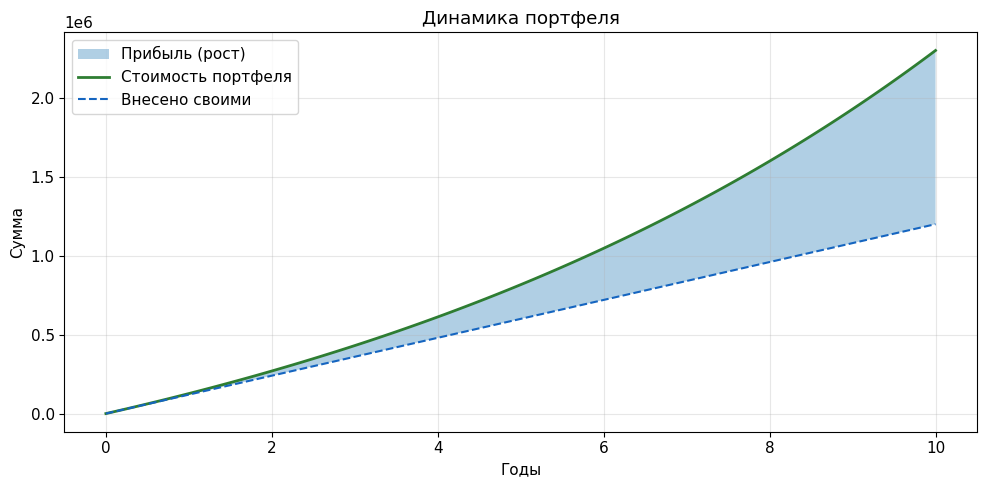

In [6]:
MONTHLY_PAYMENT = 10_000.0  # руб. в месяц
ANNUAL_RATE_PERCENT = 12.0  # % годовых
ANNUAL_INFLATION_PERCENT = 7.0  # % годовых (ожидаемая инфляция)
YEARS = 10

fv, balance, invested = future_value_monthly(MONTHLY_PAYMENT, ANNUAL_RATE_PERCENT, YEARS)
fv_today = nominal_future_in_todays_rubles(fv, ANNUAL_INFLATION_PERCENT, YEARS)
live_nom = sustainable_monthly_nominal(fv, ANNUAL_RATE_PERCENT)
live_real = sustainable_monthly_real_preserving(fv, ANNUAL_RATE_PERCENT, ANNUAL_INFLATION_PERCENT)
live_nom_today = nominal_future_in_todays_rubles(live_nom, ANNUAL_INFLATION_PERCENT, YEARS)
live_real_today = nominal_future_in_todays_rubles(live_real, ANNUAL_INFLATION_PERCENT, YEARS)
print(f"Итого на счёте (номинал): {fv:,.0f} руб.".replace(",", " "))
print(
    f"В «сегодняшних рублях» (инфляция {ANNUAL_INFLATION_PERCENT:.1f}%): {fv_today:,.0f} руб.".replace(",", " ")
)
print(f"Внесено:        {invested:,.0f} руб.".replace(",", " "))
print(f"Прибыль:        {fv - invested:,.0f} руб.".replace(",", " "))
print(
    f"Снятие в месяц (номинал): {live_nom:,.0f} руб., в сегодняшних: {live_nom_today:,.0f} руб.".replace(",", " ")
)
print(
    f"Снятие в месяц с инфляцией {ANNUAL_INFLATION_PERCENT:.1f}% (реальный капитал): {live_real:,.0f} руб., в сегодняшних: {live_real_today:,.0f} руб.".replace(
        ",", " "
    )
)
plot_growth(balance, MONTHLY_PAYMENT, YEARS)

## Режим 2: без виджетов — только доли зарплаты

Зарплата задаётся условной единицей **1 в месяц** (уровень в рублях не влияет на проценты). Измените `SAVINGS_RATE_PERCENT` и общие параметры, выполните ячейку — текст и график в **% зарплаты**.

Норма накоплений: 50% зарплаты в месяц
Капитал в конце: 62.38 годовых зарплат; внесено: 10.00 годовых зарплат
Пассив (номинал) впервые ≥ зарплаты: через 7 лет 5 мес.
Пассив (реальный капитал) впервые ≥ зарплаты: через 10 лет 6 мес.
На конец срока: безопасное снятие ≈ 935.8% и 499.1% от зарплаты


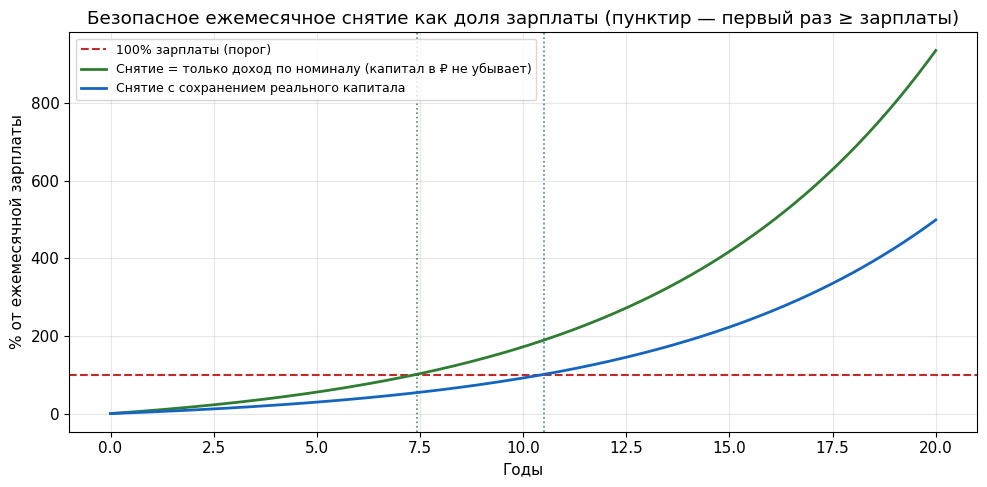

In [9]:
SALARY = 1.0  # условная месячная зарплата (масштаб не влияет на %)
SAVINGS_RATE_PERCENT = 50.0
ANNUAL_RATE_PERCENT = 15.0
ANNUAL_INFLATION_PERCENT = 7.0
YEARS = 20

monthly = SALARY * SAVINGS_RATE_PERCENT / 100.0
fv, balance, invested = future_value_monthly(monthly, ANNUAL_RATE_PERCENT, YEARS)
m_nom = first_month_withdrawal_covers_salary(balance, ANNUAL_RATE_PERCENT, SALARY, use_real=False)
m_real = first_month_withdrawal_covers_salary(
    balance, ANNUAL_RATE_PERCENT, SALARY, use_real=True, inflation_pct=ANNUAL_INFLATION_PERCENT
)
end_nom = sustainable_monthly_nominal(fv, ANNUAL_RATE_PERCENT) / SALARY * 100.0
end_real = sustainable_monthly_real_preserving(fv, ANNUAL_RATE_PERCENT, ANNUAL_INFLATION_PERCENT) / SALARY * 100.0

print(f"Норма накоплений: {SAVINGS_RATE_PERCENT:g}% зарплаты в месяц")
print(f"Капитал в конце: {fv / (12 * SALARY):.2f} годовых зарплат; внесено: {invested / (12 * SALARY):.2f} годовых зарплат")
if m_nom is None:
    print("Пассив (номинал) впервые ≥ зарплаты: не на горизонте")
else:
    print(f"Пассив (номинал) впервые ≥ зарплаты: через {format_years_months_from_idx(m_nom)}")
if m_real is None:
    print("Пассив (реальный капитал) впервые ≥ зарплаты: не на горизонте")
else:
    print(f"Пассив (реальный капитал) впервые ≥ зарплаты: через {format_years_months_from_idx(m_real)}")
print(f"На конец срока: безопасное снятие ≈ {end_nom:.1f}% и {end_real:.1f}% от зарплаты")
plot_passive_income_pct_of_salary(balance, ANNUAL_RATE_PERCENT, ANNUAL_INFLATION_PERCENT, YEARS, SALARY)

In [ ]:
100 + 135*2 + 140 

510